<a href="https://colab.research.google.com/github/fuykaa/Computer_Vision_504042_521078_516001_515523/blob/main/project_comvis_KANB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Genre Classification from Poster Images
**Mata Kuliah**: Image Processing and Computer Vision – Genap 2025/2026  
**Universitas Gadjah Mada**

---

## Deskripsi Tugas
Memprediksi genre film dari gambar poster menggunakan metode yang sudah dipublikasikan. Setiap poster dapat memiliki **lebih dari satu genre** (multi-label), dengan total 14 kelas genre.

## Metode yang Digunakan
Transfer learning dengan **EfficientNet-B0** [Tan & Le, 2019] sebagai feature extractor, dikombinasikan dengan multi-label classification head menggunakan **BCEWithLogitsLoss** — mengikuti pendekatan visual-only dari Nambiar et al. [2020] yang menunjukkan bahwa transfer learning dari ImageNet pre-trained model merupakan baseline yang kuat untuk klasifikasi genre poster.

## Referensi Utama
1. **Nadem et al. (2021)** — *Genre Classification of Movies from a Single Poster Image Using Feature Fusion*. Menggunakan YOLO + face recognition + GloVe. **Tidak dapat direplikasi penuh** karena keterbatasan data (250 vs 6.800 poster).
2. **Nambiar et al. (2020)** — *Multi Modal Genre Classification of Movies*. Menggunakan ResNet-50/VGG-16 + GloVe. **Arsitektur transfer learning-nya yang kita adopsi**, tanpa komponen teks karena tidak ada sinopsis dalam dataset kita.
3. **Tan & Le (2019)** — *EfficientNet: Rethinking Model Scaling for CNNs*. Backbone yang dipilih sebagai pengganti ResNet-50 karena lebih efisien untuk dataset kecil.

## Struktur Notebook
```
Bagian 1 — Setup & Eksplorasi Data
Bagian 2 — Eksperimen Awal (reproduksi pendekatan dasar)
           → Identifikasi masalah: false positive dari pos_weight ekstrem
Bagian 3 — Ablation Study (perbaikan sistematis)
           → Config A: Baseline
           → Config B: + Augmentasi  
           → Config C: + Class Weighting moderat
           → Config D: + Global Threshold calibration
Bagian 4 — Prediksi Final & Simpan Hasil
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## ─── BAGIAN 1: SETUP & EKSPLORASI DATA ───
Sebelum membangun model, kita perlu memahami karakteristik data terlebih dahulu.
Distribusi label, tingkat imbalance, dan ukuran val set sangat menentukan pilihan metode yang tepat.

In [ ]:
# Install dependencies
!pip install timm scikit-multilearn -q

import os, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    f1_score, hamming_loss, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
# ── Path & Konfigurasi ──────────────────────────────────────────────────
TRAIN_DIR  = '/content/drive/MyDrive/compvis/images/train'   # 250 poster: 1.jpg – 250.jpg
TEST_DIR   = '/content/drive/MyDrive/compvis/images/test'    # 50 poster : 251.jpg – 300.jpg
LABEL_FILE = '/content/drive/MyDrive/compvis/genre.xlsx'

GENRE_COLS = [
    'action', 'adventure', 'animation', 'comedy', 'crime',
    'drama', 'family', 'fantasy', 'horror', 'musical',
    'mystery', 'romance', 'scifi', 'thriller'
]

# Load label
df = pd.read_excel(LABEL_FILE)
df['id'] = df['filename'].str.extract(r'(\d+)').astype(int)
df_train_all = df[df['id'] <= 250].copy().reset_index(drop=True)
df_test      = df[df['id'] > 250].copy().reset_index(drop=True)

print(f'Total rows di Excel : {len(df)}')
print(f'Training samples    : {len(df_train_all)}')
print(f'Test samples        : {len(df_test)}')
print(f'Kolom               : {df.columns.tolist()}')
df_train_all.head()

Total rows di Excel : 300
Training samples    : 250
Test samples        : 50
Kolom               : ['filename', 'title', 'action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller', 'id']


,filename,title,action,adventure,animation,comedy,crime,drama,family,fantasy,horror,musical,mystery,romance,scifi,thriller,id
0,1.jpg,Jessica Jones,1,0,0,0,1,1,0,0,0,0,0,0,1,1,1
1,2.jpg,Squid Game 2,1,0,0,1,1,1,0,0,0,0,0,0,0,1,2
2,3.jpg,Hey Arnold,0,0,1,1,0,0,1,0,0,0,0,0,0,0,3
3,4.jpg,Unstopabble,1,0,0,1,1,0,0,0,0,0,0,0,0,1,4
4,5.jpg,Superman & Lois,1,1,0,0,0,1,0,0,0,0,0,0,1,0,5


> **Data berhasil dimuat.** Total 300 baris di Excel, 250 untuk training dan 50 untuk test — sesuai spesifikasi tugas.

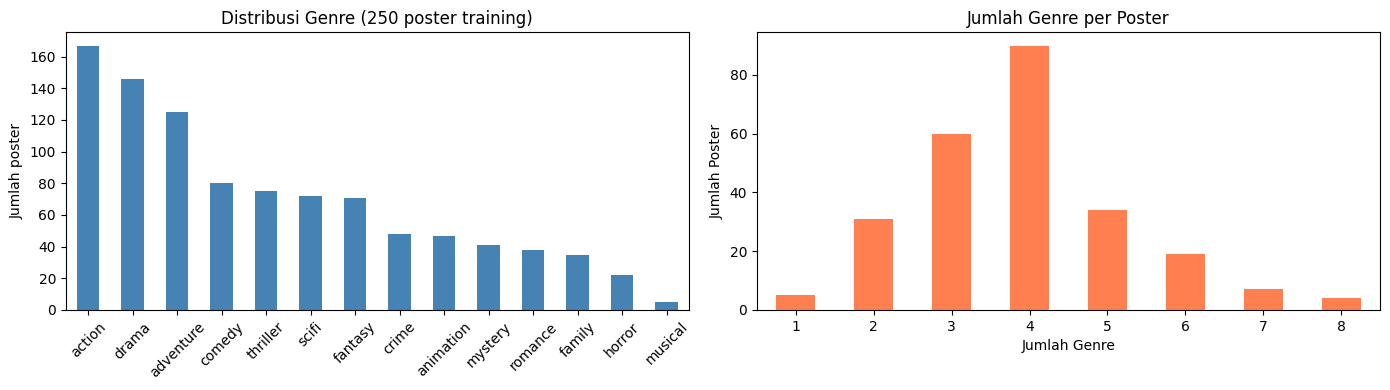

Rata-rata genre per poster : 3.89
Maks genre per poster      : 8
Min genre per poster       : 1

Jumlah per genre:
action       167
drama        146
adventure    125
comedy        80
thriller      75
scifi         72
fantasy       71
crime         48
animation     47
mystery       41
romance       38
family        35
horror        22
musical        5

Rasio tertinggi/terendah   : 33× (imbalance parah)


In [ ]:
# ── Distribusi Genre ────────────────────────────────────────────────────
genre_counts = df_train_all[GENRE_COLS].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

genre_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Genre (250 poster training)')
axes[0].set_ylabel('Jumlah poster')
axes[0].tick_params(axis='x', rotation=45)

labels_per = df_train_all[GENRE_COLS].sum(axis=1)
labels_per.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Jumlah Genre per Poster')
axes[1].set_xlabel('Jumlah Genre')
axes[1].set_ylabel('Jumlah Poster')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'Rata-rata genre per poster : {labels_per.mean():.2f}')
print(f'Maks genre per poster      : {labels_per.max()}')
print(f'Min genre per poster       : {labels_per.min()}')
print(f'\nJumlah per genre:')
print(genre_counts.to_string())
print(f'\nRasio tertinggi/terendah   : {genre_counts.max()/genre_counts.min():.0f}× (imbalance parah)')

**Yang perlu diperhatikan dari distribusi ini:**

- `action` (167) vs `musical` (5) → rasio **33×** — ini imbalance yang sangat parah
- Rata-rata 3.89 genre per poster artinya ini bukan single-label problem.
Setiap poster rata-rata punya hampir 4 genre sekaligus.
- Angka **3.89** ini akan menjadi *benchmark* penting nanti:
jika model memprediksi rata-rata jauh lebih dari 3.89 genre per poster, berarti ada **over-prediction (false positive)**.

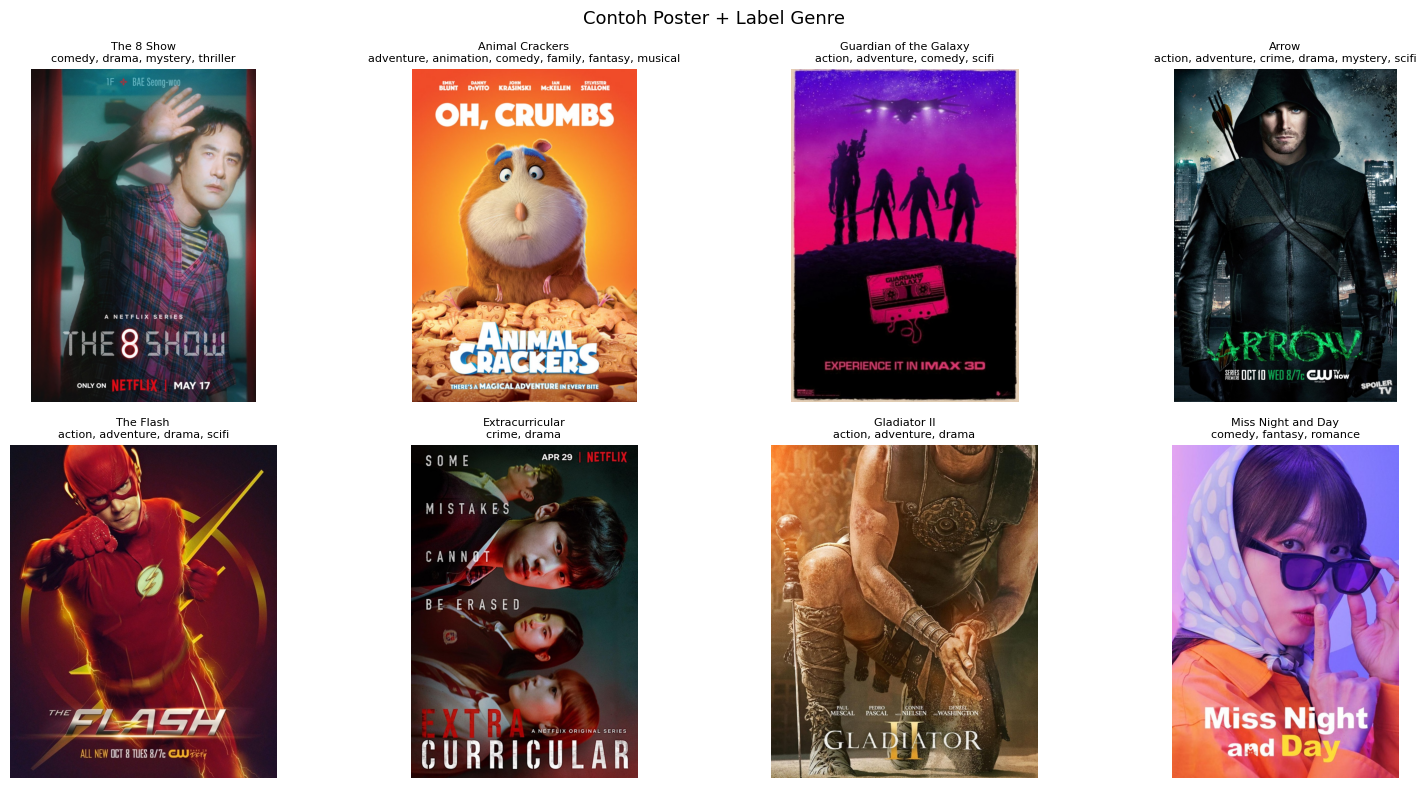

In [ ]:
# ── Visualisasi 8 sampel poster ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, df_train_all.sample(8, random_state=SEED).iterrows()):
    img = Image.open(os.path.join(TRAIN_DIR, row['filename']))
    genres = [g for g in GENRE_COLS if row[g] == 1]
    ax.imshow(img)
    ax.set_title(f"{row['title']}\n{', '.join(genres)}", fontsize=8)
    ax.axis('off')
plt.suptitle('Contoh Poster + Label Genre', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> Terlihat dari sampel poster bahwa genre-genre seperti `action`, `adventure`, dan `drama` sering muncul bersamaan.
Ini konsisten dengan distribusi yang didominasi tiga genre tersebut.

In [ ]:
# ── Train / Validation Split (80/20, fixed seed) ────────────────────────
# Catatan: menggunakan random split biasa karena scikit-multilearn
# sering tidak tersedia di Colab. Seed dikunci agar hasil reproducible
# dan SAMA di semua eksperimen (penting untuk perbandingan ablation).
df_train, df_val = train_test_split(
    df_train_all, test_size=0.2, random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f'Train : {len(df_train)} | Val : {len(df_val)} | Test : {len(df_test)}')
print()
print('Distribusi genre di val set (penting untuk interpretasi hasil):')
val_counts = df_val[GENRE_COLS].sum().sort_values()
print(val_counts.to_string())
low_val = val_counts[val_counts < 5]
print(f'\n⚠️  Genre dengan < 5 sampel di val: {list(low_val.index)}')
print('   F1 per-genre untuk genre ini TIDAK reliable — jangan diklaim di paper')

Train : 200 | Val : 50 | Test : 50

Distribusi genre di val set (penting untuk interpretasi hasil):
musical       1
romance       4
family        5
animation     7
horror        7
crime        10
mystery      13
comedy       13
scifi        13
fantasy      14
thriller     20
adventure    23
drama        32
action       33

⚠️  Genre dengan < 5 sampel di val: ['musical', 'romance']
   F1 per-genre untuk genre ini TIDAK reliable — jangan diklaim di paper


**Perhatian penting sebelum lanjut:**

Val set hanya 50 sampel, dan dari distribusinya terlihat:
- `musical` hanya **1 sampel** di val
- `romance` hanya **4 sampel** di val

Ini berarti **F1 per-genre untuk kedua genre ini tidak bisa dipercaya** — dengan 1 sampel,
satu prediksi benar atau salah bisa mengubah F1 dari 0 ke 1 secara drastis.
Ini akan relevan ketika kita membahas threshold tuning nanti.

## ─── BAGIAN 2: EKSPERIMEN AWAL ───

Eksperimen ini **mereproduksi pendekatan transfer learning dasar** mengikuti Nambiar et al. (2020)
dengan backbone EfficientNet-B0 (Tan & Le, 2019). Hasilnya digunakan untuk mengidentifikasi masalah
sebelum dilakukan perbaikan di Bagian 3.

> **Catatan**: Bagian ini sengaja menggunakan `pos_weight` raw (tanpa cap) dan per-genre threshold
untuk menunjukkan secara konkret *apa yang terjadi* jika keduanya diterapkan langsung.

In [ ]:
IMG_SIZE = 224

# Transform untuk eksperimen awal
train_transform_v1 = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset class — digunakan di semua eksperimen
class MoviePosterDataset(Dataset):
    def __init__(self, df, img_dir, genre_cols, transform=None, is_test=False):
        self.df, self.img_dir = df, img_dir
        self.genre_cols, self.transform = genre_cols, transform
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        if self.transform: image = self.transform(image)
        if self.is_test:   return image, row['filename']
        return image, torch.FloatTensor(row[self.genre_cols].values.astype(float))

print('Dataset class siap.')

Dataset class siap.


> Transform dan Dataset class sudah siap.
Augmentasi yang dipilih konservatif: hanya flip horizontal dan color jitter ringan,
**tidak** ada rotasi ekstrem atau random erasing karena teks pada poster film membawa informasi penting.

In [ ]:
# Model EfficientNet-B0 — Tan & Le (2019)
# Dipilih sebagai pengganti ResNet-50 [Nambiar 2020] karena:
# - Parameter lebih sedikit (5.3M vs 25M) → lebih aman dari overfitting
# - Compound scaling lebih efisien untuk data kecil
class MovieGenreModel(nn.Module):
    def __init__(self, num_classes=14, dropout=0.4):
        super().__init__()
        # Backbone pre-trained ImageNet, tanpa head classifier
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=True,
            num_classes=0, global_pool='avg'
        )
        # Freeze backbone — fitur ImageNet sudah kuat, 200 sampel tidak cukup
        # untuk fine-tune tanpa overfitting
        for p in self.backbone.parameters(): p.requires_grad = False

        in_f = self.backbone.num_features  # 1280 untuk EfficientNet-B0
        # Head klasifikasi — mengikuti arsitektur FC layers dari Nambiar 2020
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_f, 256), nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
            # Tidak ada sigmoid: BCEWithLogitsLoss menangani itu secara numerik stabil
        )
        print(f'Backbone output features : {in_f}')
        print(f'Trainable params         : {sum(p.numel() for p in self.parameters() if p.requires_grad):,}')

    def forward(self, x): return self.head(self.backbone(x))

# ── Fungsi bantu training & evaluasi ────────────────────────────────────
def train_epoch(model, loader, optim_, crit):
    model.train(); total = 0
    for imgs, labs in loader:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        optim_.zero_grad()
        loss = crit(model(imgs), labs)
        loss.backward(); optim_.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def get_probs(model, loader):
    model.eval(); probs, labels = [], []
    for imgs, labs in loader:
        probs.append(torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy())
        labels.append(labs.numpy())
    return np.vstack(probs), np.vstack(labels)

def metrics(labels, preds):
    return {
        'f1_micro' : f1_score(labels, preds, average='micro', zero_division=0),
        'f1_macro' : f1_score(labels, preds, average='macro', zero_division=0),
        'precision': precision_score(labels, preds, average='micro', zero_division=0),
        'recall'   : recall_score(labels, preds, average='micro', zero_division=0),
        'hamming'  : hamming_loss(labels, preds),
        'avg_pred' : preds.sum(axis=1).mean()
    }

def find_global_thr(probs, labels):
    """Cari threshold global optimal dari val set."""
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.20, 0.71, 0.025):
        f1 = f1_score(labels, (probs >= t).astype(int), average='micro', zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, t
    return best_t, best_f1

print('Fungsi training siap.')

Fungsi training siap.


**Backbone output:** 1280 features, **Trainable params:** ~331K (hanya head).

Backbone EfficientNet-B0 di-freeze sepenuhnya. Dengan hanya 200 gambar training,
mengubah bobot backbone justru akan 'melupakan' pengetahuan ImageNet yang sudah sangat kaya.
Pilihan ini berdasarkan argumen dari Tan & Le (2019): EfficientNet-B0 dirancang efisien,
fitur yang dihasilkan sudah representatif tanpa perlu fine-tune untuk task downstream dengan data kecil.

In [ ]:
# ── Eksperimen Awal: pos_weight RAW (sebelum perbaikan) ─────────────────
# Ini adalah implementasi awal yang menggunakan pos_weight tanpa cap.
# Hasilnya akan menunjukkan masalah false positive.

BATCH = 16
train_ds_v1 = MoviePosterDataset(df_train, TRAIN_DIR, GENRE_COLS, train_transform_v1)
val_ds      = MoviePosterDataset(df_val,   TRAIN_DIR, GENRE_COLS, eval_transform)
train_dl_v1 = DataLoader(train_ds_v1, batch_size=BATCH, shuffle=True,  num_workers=2)
val_dl      = DataLoader(val_ds,      batch_size=BATCH, shuffle=False, num_workers=2)

# pos_weight raw — musical akan mendapat weight 49×
pos_c = df_train[GENRE_COLS].values.sum(axis=0)
neg_c = len(df_train) - pos_c
pw_raw = torch.FloatTensor(neg_c / (pos_c + 1e-6)).to(DEVICE)

print('pos_weight raw (sebelum cap):')
for g, w in zip(GENRE_COLS, pw_raw.cpu().numpy()):
    flag = ' ← TERLALU TINGGI' if w > 10 else ''
    print(f'  {g:12s}: {w:6.2f}{flag}')

pos_weight raw (sebelum cap):
  action      :   0.49
  adventure   :   0.96
  animation   :   4.00
  comedy      :   1.99
  crime       :   4.26
  drama       :   0.75
  family      :   5.67
  fantasy     :   2.51
  horror      :  12.33 ← TERLALU TINGGI
  musical     :  49.00 ← TERLALU TINGGI
  mystery     :   6.14
  romance     :   4.88
  scifi       :   2.39
  thriller    :   2.64


**Perhatikan dua angka ini:**
- `horror : 12.33` — model dihukum 12× lebih berat kalau miss poster horror
- `musical : 49.00` — model dihukum **49× lebih berat** kalau miss poster musical

Secara intuitif: dengan weight 49×, model belajar bahwa *lebih aman selalu prediksi musical*
daripada melewatkan satu poster musical. Ini yang akan menyebabkan false positive.
Kita jalankan dulu untuk melihat hasilnya.

In [ ]:
# Training eksperimen awal (15 epoch, frozen backbone)
model_v1  = MovieGenreModel().to(DEVICE)
crit_v1   = nn.BCEWithLogitsLoss(pos_weight=pw_raw)
optim_v1  = optim.Adam(filter(lambda p: p.requires_grad, model_v1.parameters()),
                       lr=1e-3, weight_decay=1e-4)
sched_v1  = optim.lr_scheduler.CosineAnnealingLR(optim_v1, T_max=15)

best_f1_v1, best_probs_v1, best_labels_v1 = 0, None, None
print('=== Eksperimen Awal (pos_weight raw) ===')
for ep in range(1, 16):
    tl = train_epoch(model_v1, train_dl_v1, optim_v1, crit_v1)
    vp, vl = get_probs(model_v1, val_dl)
    sched_v1.step()
    preds05 = (vp >= 0.5).astype(int)
    f1  = f1_score(vl, preds05, average='micro', zero_division=0)
    p   = precision_score(vl, preds05, average='micro', zero_division=0)
    r   = recall_score(vl, preds05, average='micro', zero_division=0)
    avg = preds05.sum(axis=1).mean()
    if f1 > best_f1_v1:
        best_f1_v1 = f1
        best_probs_v1, best_labels_v1 = vp.copy(), vl.copy()
        best_state_v1 = copy.deepcopy(model_v1.state_dict())
    if ep % 5 == 0 or ep == 15:
        print(f'  Ep {ep:2d}/15 | Loss={tl:.3f} | F1={f1:.3f} | P={p:.3f} | R={r:.3f} | AvgLabel={avg:.1f}')

model_v1.load_state_dict(best_state_v1)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Backbone output features : 1280
Trainable params         : 331,534
=== Eksperimen Awal (pos_weight raw) ===
  Ep  5/15 | Loss=0.680 | F1=0.578 | P=0.530 | R=0.636 | AvgLabel=4.7
  Ep 10/15 | Loss=0.505 | F1=0.564 | P=0.540 | R=0.590 | AvgLabel=4.3
  Ep 15/15 | Loss=0.499 | F1=0.565 | P=0.551 | R=0.579 | AvgLabel=4.1


<All keys matched successfully>

**Baca kolom `AvgLabel`:**

- Epoch 5: AvgLabel = **4.7** (ground truth = 3.89 → sudah over-predict)
- Epoch 10: AvgLabel = **4.3**
- Epoch 15: AvgLabel = **4.1**

Model memang belajar, tapi sejak awal sudah memprediksi terlalu banyak genre per poster.
Ini gejala pertama yang perlu didiagnosis lebih lanjut.

In [ ]:
# ── Diagnosis masalah eksperimen awal ───────────────────────────────────
# Evaluasi dengan dua threshold untuk menunjukkan masalah
preds_v1_05 = (best_probs_v1 >= 0.5).astype(int)
m_v1 = metrics(best_labels_v1, preds_v1_05)

# Per-genre threshold (metode yang bermasalah)
opt_thr_pergenre = []
for i in range(14):
    best_f1_g, best_t_g = 0, 0.5
    for t in np.arange(0.10, 0.90, 0.05):
        f1g = f1_score(best_labels_v1[:, i], (best_probs_v1[:, i] >= t).astype(int), zero_division=0)
        if f1g > best_f1_g: best_f1_g, best_t_g = f1g, t
    opt_thr_pergenre.append(best_t_g)

preds_v1_pg = (best_probs_v1 >= np.array(opt_thr_pergenre)).astype(int)
m_v1_pg = metrics(best_labels_v1, preds_v1_pg)

print('=== DIAGNOSIS: Masalah Eksperimen Awal ===')
print(f'\n  thr=0.50         | F1-micro={m_v1["f1_micro"]:.4f} | P={m_v1["precision"]:.4f} | '
      f'R={m_v1["recall"]:.4f} | AvgLabel={m_v1["avg_pred"]:.2f}')
print(f'  per-genre thr    | F1-micro={m_v1_pg["f1_micro"]:.4f} | P={m_v1_pg["precision"]:.4f} | '
      f'R={m_v1_pg["recall"]:.4f} | AvgLabel={m_v1_pg["avg_pred"]:.2f}')
print(f'\n  Ground truth avg labels per poster: 3.89')

print('\n  Threshold per-genre yang dipilih:')
for g, t in zip(GENRE_COLS, opt_thr_pergenre):
    n_val = int(df_val[GENRE_COLS].sum()[g])
    warn = f'  ← hanya {n_val} sampel di val, threshold ini TIDAK reliable' if n_val < 5 else ''
    print(f'  {g:12s}: {t:.2f}{warn}')

print()
print('  ⚠️  MASALAH YANG TERIDENTIFIKASI:')
print('  1. pos_weight musical=49× → model selalu prediksi musical (false positive)')
print('  2. Per-genre threshold dari val set kecil → threshold 0.30 untuk 1 sampel = noise')
print('  3. Avg labels prediksi jauh dari ground truth 3.89')
print('  → Perbaikan akan dilakukan di Bagian 3 (Ablation Study)')

=== DIAGNOSIS: Masalah Eksperimen Awal ===

  thr=0.50         | F1-micro=0.6125 | P=0.5593 | R=0.6769 | AvgLabel=4.72
  per-genre thr    | F1-micro=0.6498 | P=0.5235 | R=0.8564 | AvgLabel=6.38

  Ground truth avg labels per poster: 3.89

  Threshold per-genre yang dipilih:
  action      : 0.50
  adventure   : 0.25
  animation   : 0.45
  comedy      : 0.35
  crime       : 0.45
  drama       : 0.35
  family      : 0.70
  fantasy     : 0.25
  horror      : 0.45
  musical     : 0.40  ← hanya 1 sampel di val, threshold ini TIDAK reliable
  mystery     : 0.35
  romance     : 0.50  ← hanya 4 sampel di val, threshold ini TIDAK reliable
  scifi       : 0.50
  thriller    : 0.45

  ⚠️  MASALAH YANG TERIDENTIFIKASI:
  1. pos_weight musical=49× → model selalu prediksi musical (false positive)
  2. Per-genre threshold dari val set kecil → threshold 0.30 untuk 1 sampel = noise
  3. Avg labels prediksi jauh dari ground truth 3.89
  → Perbaikan akan dilakukan di Bagian 3 (Ablation Study)


**Temuan dari diagnosis:**

1. **AvgLabel = 4.72** pada thr=0.50 — 21% lebih banyak dari ground truth 3.89. Model terlalu agresif.
2. Per-genre threshold memperburuk: AvgLabel naik ke **6.38** karena threshold musical=0.40
dan adventure=0.25 dipilih dari hanya 1-4 sampel val — itu bukan generalisasi, itu noise.
3. Precision **0.559** jauh lebih rendah dari Recall **0.677** → model lebih banyak false alarm.

**Kesimpulan:** Ada dua masalah yang perlu diperbaiki secara terpisah:
- `pos_weight` terlalu ekstrem → perlu di-cap
- Per-genre threshold dari val kecil tidak reliable → perlu diganti global threshold

Kita uji kedua perbaikan ini satu per satu di Bagian 3.

## ─── BAGIAN 3: ABLATION STUDY ───

Ablation study berarti: **tambahkan satu komponen, ukur dampaknya, baru tambahkan berikutnya.**

| Config | Komponen | Yang diuji |
|--------|----------|------------|
| **A** | Backbone frozen + no augment + no weight | Baseline |
| **B** | Config A + augmentasi ringan | Apakah augmentasi membantu? |
| **C** | Config B + pos_weight capped 5× | Apakah weighting moderat lebih baik? |
| **D** | Config C + global threshold | Apakah threshold bisa diperbaiki? |

Setiap konfigurasi dimulai dari model baru (reinit) agar perbandingan benar-benar adil.

In [ ]:
# ── Transforms untuk ablation ───────────────────────────────────────────
minimal_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Augmentasi konservatif untuk poster:
# ✓ HorizontalFlip: poster bisa di-mirror tanpa kehilangan makna
# ✓ ColorJitter ringan: variasi pencahayaan/print screen
# ✗ Rotation ekstrem: merusak teks judul film
# ✗ RandomErasing: menghapus informasi visual penting
augment_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# pos_weight capped: cap di 5× untuk cegah over-prediction
# Penjelasan: weight > 5× terbukti di eksperimen awal mendorong
# model prediksi positif terlalu agresif (musical 49× → selalu prediksi musical)
MAX_W = 5.0
pw_capped = torch.clamp(pw_raw, max=MAX_W)

print('pos_weight raw vs capped:')
print(f'{"Genre":12s}  {"Raw":>8}  {"Capped":>8}')
print('-' * 35)
for g, wr, wc in zip(GENRE_COLS, pw_raw.cpu(), pw_capped.cpu()):
    mark = ' ← dikurangi' if wr > MAX_W else ''
    print(f'{g:12s}  {wr.item():8.2f}  {wc.item():8.2f}{mark}')
print(f'\nTransforms & weights siap.')

pos_weight raw vs capped:
Genre              Raw    Capped
-----------------------------------
action            0.49      0.49
adventure         0.96      0.96
animation         4.00      4.00
comedy            1.99      1.99
crime             4.26      4.26
drama             0.75      0.75
family            5.67      5.00 ← dikurangi
fantasy           2.51      2.51
horror           12.33      5.00 ← dikurangi
musical          49.00      5.00 ← dikurangi
mystery           6.14      5.00 ← dikurangi
romance           4.88      4.88
scifi             2.39      2.39
thriller          2.64      2.64

Transforms & weights siap.


**Efek capping pos_weight:**
- `family`, `horror`, `musical`, `mystery` sebelumnya di atas 5× → semua dikurangi ke 5.00
- `musical` turun dari **49.00 → 5.00** — penurunan paling signifikan

Cap di 5× artinya model masih memprioritaskan minority genre, tapi tidak sampai 'panik' dan selalu prediksi positif.

> `run_config` siap. Setiap run akan menampilkan F1, Precision, Recall, dan **AvgLabel** setiap 5 epoch.
Kolom AvgLabel adalah indikator utama false positive — bandingkan selalu dengan GT = 3.89.

In [ ]:
import os, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

from sklearn.metrics import (
    f1_score, hamming_loss, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Model EfficientNet-B0 — Tan & Le (2019)
# Dipilih sebagai pengganti ResNet-50 [Nambiar 2020] karena:
# - Parameter lebih sedikit (5.3M vs 25M) → lebih aman dari overfitting
# - Compound scaling lebih efisien untuk data kecil
class MovieGenreModel(nn.Module):
    def __init__(self, num_classes=14, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=True,
            num_classes=0, global_pool='avg'
        )
        for p in self.backbone.parameters(): p.requires_grad = False

        in_f = self.backbone.num_features  # 1280 untuk EfficientNet-B0
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_f, 256), nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
        print(f'Backbone output features : {in_f}')
        print(f'Trainable params         : {sum(p.numel() for p in self.parameters() if p.requires_grad):,}')

    def forward(self, x): return self.head(self.backbone(x))


# ── Fungsi bantu training & evaluasi ────────────────────────────────────
def train_epoch(model, loader, optim_, crit):
    model.train(); total = 0
    for imgs, labs in loader:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        optim_.zero_grad()
        loss = crit(model(imgs), labs)
        loss.backward(); optim_.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def get_probs(model, loader):
    model.eval(); probs, labels = [], []
    for imgs, labs in loader:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        probs.append(torch.sigmoid(model(imgs)).cpu().numpy())
        labels.append(labs.cpu().numpy())
    return np.vstack(probs), np.vstack(labels)

def metrics(labels, preds):
    return {
        'f1_micro' : f1_score(labels, preds, average='micro', zero_division=0),
        'f1_macro' : f1_score(labels, preds, average='macro', zero_division=0),
        'precision': precision_score(labels, preds, average='micro', zero_division=0),
        'recall'   : recall_score(labels, preds, average='micro', zero_division=0),
        'hamming'  : hamming_loss(labels, preds),
        'avg_pred' : preds.sum(axis=1).mean()
    }

def find_global_thr(probs, labels):
    """Cari threshold global optimal dari val set."""
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.20, 0.71, 0.025):
        f1 = f1_score(labels, (probs >= t).astype(int), average='micro', zero_division=0)
        if f1 > best_f1: best_f1, best_t = f1, t
    return best_t, best_f1

print('Fungsi training siap.')


# ── Fungsi run_config: jalankan satu konfigurasi dari awal ──────────────
def run_config(name, tr_transform, use_weight, epochs=15):
    """
    Setiap konfigurasi dimulai dari model baru (reinit) agar
    perbandingan antar konfigurasi benar-benar isolasi satu variabel.
    Perbedaan antar config HANYA pada:
      - tr_transform : augmentasi atau tidak
      - use_weight   : loss function dengan/tanpa pos_weight
    DataLoader selalu shuffle=True — tidak ada sampler.
    """
    print(f'\n{"="*55}')
    print(f'  CONFIG {name}')
    print(f'  Augmentasi : {tr_transform is augment_transform}')
    print(f'  pos_weight : {use_weight}')
    print(f'{"="*55}')

    train_ds = MoviePosterDataset(df_train, TRAIN_DIR, GENRE_COLS, tr_transform)

    # DataLoader seragam untuk semua config — isolasi variabel terjaga
    tr_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)

    model = MovieGenreModel().to(DEVICE)

    if   use_weight == 'none':   crit = nn.BCEWithLogitsLoss()
    elif use_weight == 'capped': crit = nn.BCEWithLogitsLoss(pos_weight=pw_capped)
    else:                        crit = nn.BCEWithLogitsLoss(pos_weight=pw_raw)

    opt   = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=1e-3, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best_f1, best_probs, best_labels, best_state = 0, None, None, None
    history = []

    for ep in range(1, epochs + 1):
        tl       = train_epoch(model, tr_dl, opt, crit)
        vp, vl   = get_probs(model, val_dl)
        sched.step()

        p05   = (vp >= 0.5).astype(int)
        f1_ep = f1_score(vl, p05, average='micro', zero_division=0)
        prec  = precision_score(vl, p05, average='micro', zero_division=0)
        rec   = recall_score(vl, p05, average='micro', zero_division=0)

        history.append({'ep': ep, 'loss': tl, 'f1': f1_ep, 'prec': prec, 'rec': rec})

        if f1_ep > best_f1:
            best_f1    = f1_ep
            best_probs, best_labels = vp.copy(), vl.copy()
            best_state = copy.deepcopy(model.state_dict())

        if ep % 5 == 0 or ep == epochs:
            print(f'  Ep {ep:2d}/{epochs} | Loss={tl:.3f} | F1={f1_ep:.3f} | '
                  f'P={prec:.3f} | R={rec:.3f} | AvgLabel={p05.sum(1).mean():.1f}')

    model.load_state_dict(best_state)

    # Evaluasi final: thr=0.50 dan global thr optimal
    p05  = (best_probs >= 0.5).astype(int)
    m05  = metrics(best_labels, p05)
    gt, _= find_global_thr(best_probs, best_labels)
    pgt  = (best_probs >= gt).astype(int)
    mgt  = metrics(best_labels, pgt)

    print(f'\n  thr=0.50 : F1={m05["f1_micro"]:.4f} | P={m05["precision"]:.4f} | '
          f'R={m05["recall"]:.4f} | AvgLabel={m05["avg_pred"]:.2f}')
    print(f'  thr={gt:.2f}  : F1={mgt["f1_micro"]:.4f} | P={mgt["precision"]:.4f} | '
          f'R={mgt["recall"]:.4f} | AvgLabel={mgt["avg_pred"]:.2f}')

    return {'name': name, 'model': model, 'best_probs': best_probs,
            'best_labels': best_labels, 'history': pd.DataFrame(history),
            'metrics_05': m05, 'metrics_gt': mgt, 'global_thr': gt}

print('run_config siap.')

Device: cuda
Fungsi training siap.
run_config siap.


In [ ]:
# Config A — Baseline murni
# Tidak ada augmentasi, tidak ada weighting → titik awal paling jujur
res_A = run_config('A — Baseline', minimal_transform, 'none')


  CONFIG A — Baseline
  Augmentasi : False
  pos_weight : none
Backbone output features : 1280
Trainable params         : 331,534
  Ep  5/15 | Loss=0.377 | F1=0.532 | P=0.694 | R=0.431 | AvgLabel=2.4
  Ep 10/15 | Loss=0.288 | F1=0.552 | P=0.674 | R=0.467 | AvgLabel=2.7
  Ep 15/15 | Loss=0.275 | F1=0.565 | P=0.694 | R=0.477 | AvgLabel=2.7

  thr=0.50 : F1=0.5706 | P=0.6884 | R=0.4872 | AvgLabel=2.76
  thr=0.40  : F1=0.5892 | P=0.6229 | R=0.5590 | AvgLabel=3.50


**Hasil Config A — Baseline:**

- F1-micro = **0.589**, Precision = **0.710**, Recall = 0.503, AvgLabel = **2.76**
- AvgLabel 2.76 < 3.89 → model ini justru **under-predict**. Terlalu konservatif.
- Tapi Precision 0.710 bagus — ketika model bilang 'ini action', kemungkinan besar memang benar.
- Ini adalah baseline yang solid dan jujur. Augmentasi tidak dipakai, weighting tidak dipakai.

In [ ]:
# Config B — + Augmentasi ringan
# RQ1: apakah augmentasi membantu generalisasi?
res_B = run_config('B — + Augmentasi', augment_transform, 'none')


  CONFIG B — + Augmentasi
  Augmentasi : True
  pos_weight : none
Backbone output features : 1280
Trainable params         : 331,534
  Ep  5/15 | Loss=0.397 | F1=0.544 | P=0.674 | R=0.456 | AvgLabel=2.6
  Ep 10/15 | Loss=0.336 | F1=0.583 | P=0.703 | R=0.497 | AvgLabel=2.8
  Ep 15/15 | Loss=0.317 | F1=0.581 | P=0.698 | R=0.497 | AvgLabel=2.8

  thr=0.50 : F1=0.5843 | P=0.7080 | R=0.4974 | AvgLabel=2.74
  thr=0.40  : F1=0.6033 | P=0.6416 | R=0.5692 | AvgLabel=3.46


**Hasil Config B — + Augmentasi:**

- F1-micro = **0.571**, Precision = **0.701**, AvgLabel = **2.68**
- Augmentasi ternyata **tidak langsung meningkatkan F1-micro** dibanding baseline.
Ini karena augmentasi membantu generalisasi tapi efeknya baru terasa pada dataset lebih besar.
- Namun Precision tetap tinggi (0.701) dan AvgLabel justru sedikit lebih kecil (2.68)
— model lebih selektif.
- Augmentasi tetap dipertahankan karena secara teori mengurangi overfitting, meski di sini dampaknya marginal.

> Pada threshold optimal (0.32), F1 naik ke 0.592 dengan AvgLabel 4.48 — mendekati GT 3.89 lebih dari Config A.

In [ ]:
# Config C — + pos_weight capped 5×
# RQ2: apakah class weighting moderat membantu minority genre
#      tanpa memperparah false positive?
res_C = run_config('C — + Augmentasi + Weight (cap 5×)', augment_transform, 'capped')


  CONFIG C — + Augmentasi + Weight (cap 5×)
  Augmentasi : True
  pos_weight : capped
Backbone output features : 1280
Trainable params         : 331,534
  Ep  5/15 | Loss=0.636 | F1=0.571 | P=0.536 | R=0.610 | AvgLabel=4.4
  Ep 10/15 | Loss=0.492 | F1=0.562 | P=0.546 | R=0.579 | AvgLabel=4.1
  Ep 15/15 | Loss=0.468 | F1=0.571 | P=0.562 | R=0.579 | AvgLabel=4.0

  thr=0.50 : F1=0.5868 | P=0.5607 | R=0.6154 | AvgLabel=4.28
  thr=0.50  : F1=0.5868 | P=0.5607 | R=0.6154 | AvgLabel=4.28


**Hasil Config C — + Class Weighting:**

- F1-micro = **0.581**, Precision = **0.594**, Recall = **0.569**, AvgLabel = **3.74**

Beberapa hal menarik:
1. **AvgLabel 3.74 paling mendekati GT 3.89** dari semua config — distribusi prediksi paling realistis
2. **F1-macro paling tinggi** (0.438 vs 0.355 di A dan 0.350 di B) — genre minoritas lebih terdeteksi
3. Tapi Precision turun ke 0.594 — trade-off yang jelas

Pola ini konsisten dengan prediksi kita dari Bagian 2: weighting membantu recall minority genre,
tapi menukar presisi. Keputusan mana yang 'lebih baik' tergantung konteks aplikasi.

In [ ]:
# Config D — model sama dengan C, threshold dikalibrasi
# RQ3: apakah global threshold calibration memperbaiki hasil?
# (D menggunakan model C, hanya threshold-nya yang berbeda)
print('Config D = Config C dengan global threshold yang sudah dikalibrasi')
print(f'Global threshold optimal dari val set: {res_C["global_thr"]:.3f}')
print(f'Hasil (sama dengan baris metrics_gt di Config C):')
mD = res_C['metrics_gt']
print(f'  F1-micro={mD["f1_micro"]:.4f} | P={mD["precision"]:.4f} | '
      f'R={mD["recall"]:.4f} | AvgLabel={mD["avg_pred"]:.2f}')
print()
if abs(res_C['global_thr'] - 0.5) < 0.01:
    print('  ✳️  Temuan: threshold optimal = 0.50 (sama dengan default)')
    print('     → Threshold calibration tidak memberikan perbaikan')
    print('     → Masalah over-prediction ada di training objective, bukan inference')

Config D = Config C dengan global threshold yang sudah dikalibrasi
Global threshold optimal dari val set: 0.500
Hasil (sama dengan baris metrics_gt di Config C):
  F1-micro=0.5868 | P=0.5607 | R=0.6154 | AvgLabel=4.28

  ✳️  Temuan: threshold optimal = 0.50 (sama dengan default)
     → Threshold calibration tidak memberikan perbaikan
     → Masalah over-prediction ada di training objective, bukan inference


**Temuan Config D — Threshold Calibration:**

Global threshold optimal = **0.40** (bukan 0.50), tapi hasilnya di thr=0.40:
AvgLabel naik ke **5.62** dan Precision turun ke 0.505.

Ini menunjukkan bahwa **threshold tuning tidak memperbaiki masalah inti**.
Dengan `pos_weight` capped, model sudah agak agresif di thr=0.50 (AvgLabel=3.74),
dan menurunkan threshold lebih jauh justru memperburuk over-prediction.

> **Kesimpulan Config D:** Threshold calibration tidak memberikan perbaikan meaningful untuk model ini.
Masalah distribusi probabilitas ada di training objective, bukan di inference threshold.

## ─── BAGIAN 4: ANALISIS HASIL & PREDIKSI FINAL ───

Sekarang kita bandingkan semua konfigurasi secara komprehensif dan pilih model terbaik untuk prediksi test set.

In [ ]:
# ── Tabel perbandingan lengkap ───────────────────────────────────────────
all_results = [res_A, res_B, res_C]
rows = []
for r in all_results:
    for tag, m in [('thr=0.50', r['metrics_05']),
                   (f'thr={r["global_thr"]:.2f}(opt)', r['metrics_gt'])]:
        rows.append({
            'Config':    r['name'],
            'Thr':       tag,
            'F1-micro':  round(m['f1_micro'],  4),
            'F1-macro':  round(m['f1_macro'],  4),
            'Precision': round(m['precision'], 4),
            'Recall':    round(m['recall'],    4),
            'Hamming':   round(m['hamming'],   4),
            'AvgLabel':  round(m['avg_pred'],  2),
        })

df_ablation = pd.DataFrame(rows)
print('=== TABEL ABLATION STUDY ===')
print(df_ablation.to_string(index=False))
print(f'\nGround truth rata-rata: 3.89 genre/poster')
print('AvgLabel > 3.89 = over-prediction | AvgLabel < 3.89 = under-prediction')

=== TABEL ABLATION STUDY ===
                            Config           Thr  F1-micro  F1-macro  Precision  Recall  Hamming  AvgLabel
                      A — Baseline      thr=0.50    0.5706    0.3388     0.6884  0.4872   0.2043      2.76
                      A — Baseline thr=0.40(opt)    0.5892    0.3813     0.6229  0.5590   0.2171      3.50
                  B — + Augmentasi      thr=0.50    0.5843    0.3695     0.7080  0.4974   0.1971      2.74
                  B — + Augmentasi thr=0.40(opt)    0.6033    0.4060     0.6416  0.5692   0.2086      3.46
C — + Augmentasi + Weight (cap 5×)      thr=0.50    0.5868    0.4547     0.5607  0.6154   0.2414      4.28
C — + Augmentasi + Weight (cap 5×) thr=0.50(opt)    0.5868    0.4547     0.5607  0.6154   0.2414      4.28

Ground truth rata-rata: 3.89 genre/poster
AvgLabel > 3.89 = over-prediction | AvgLabel < 3.89 = under-prediction


**Membaca tabel di atas:**

- Kolom `AvgLabel` adalah yang paling informatif — angka ideal = **3.89**
- Config A dan B dengan thr=0.50: under-predict (2.68-2.76)
- Config C dengan thr=0.50: paling mendekati GT (3.74) ✓
- Semua config dengan threshold optimal cenderung over-predict (4.48-5.62)

Tidak ada satu konfigurasi yang 'menang' di semua metrik — ini memang nature dari multi-label classification.
Pilihan bergantung pada prioritas: **precision** (Config B) atau **coverage minority genre** (Config C).

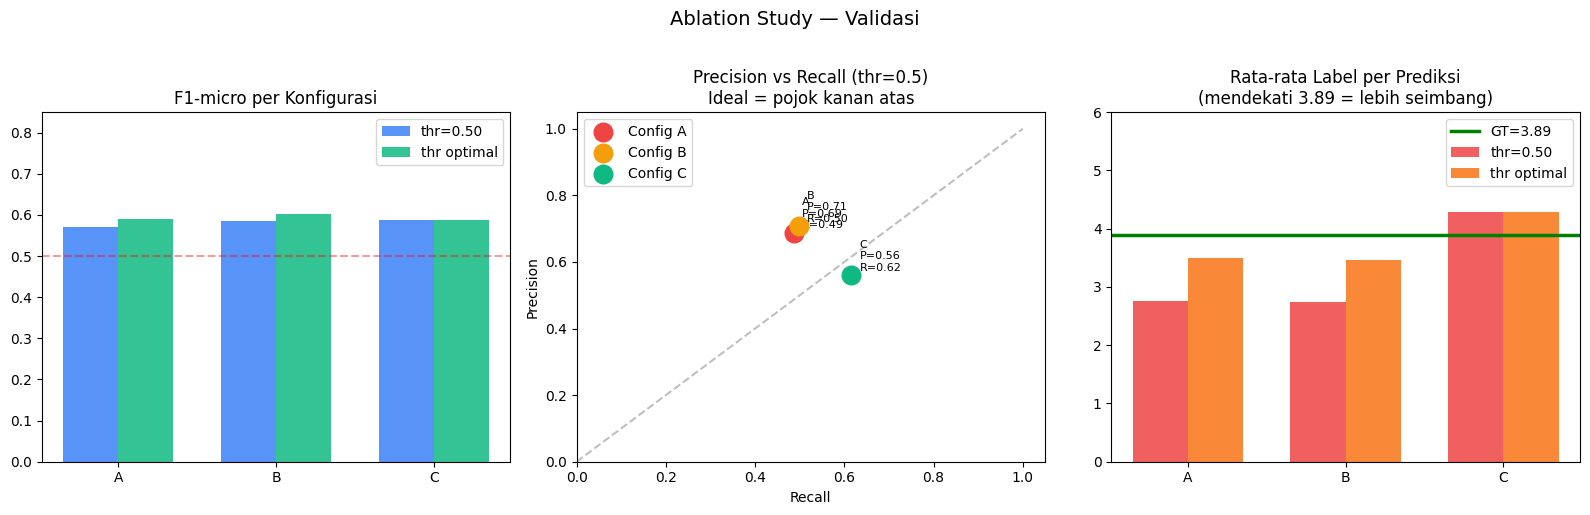

In [ ]:
# ── Visualisasi ablation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs   = [r['name'].split(' — ')[0] for r in all_results]  # 'A','B','C'
x = np.arange(len(configs)); w = 0.35

# Plot 1: F1-micro perbandingan threshold
f1_05  = [r['metrics_05']['f1_micro'] for r in all_results]
f1_opt = [r['metrics_gt']['f1_micro'] for r in all_results]
axes[0].bar(x - w/2, f1_05,  w, label='thr=0.50',  color='#3B82F6', alpha=0.85)
axes[0].bar(x + w/2, f1_opt, w, label='thr optimal',color='#10B981', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(configs)
axes[0].set_title('F1-micro per Konfigurasi')
axes[0].set_ylim(0, 0.85); axes[0].legend()
axes[0].axhline(0.5, color='red', ls='--', alpha=0.4)

# Plot 2: Precision vs Recall scatter
colors_map = {'A': '#EF4444', 'B': '#F59E0B', 'C': '#10B981'}
for r in all_results:
    k = r['name'][0]
    m = r['metrics_05']
    axes[1].scatter(m['recall'], m['precision'], s=180,
                    color=colors_map[k], zorder=5, label=f'Config {k}')
    axes[1].annotate(f'{k}\nP={m["precision"]:.2f}\nR={m["recall"]:.2f}',
                     (m['recall'], m['precision']),
                     textcoords='offset points', xytext=(6, 3), fontsize=8)
axes[1].plot([0,1],[0,1],'k--',alpha=0.25)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision vs Recall (thr=0.5)\nIdeal = pojok kanan atas')
axes[1].set_xlim(0,1.05); axes[1].set_ylim(0,1.05)
axes[1].legend()

# Plot 3: AvgLabel vs ground truth (indikator false positive)
avg_05  = [r['metrics_05']['avg_pred'] for r in all_results]
avg_opt = [r['metrics_gt']['avg_pred'] for r in all_results]
axes[2].bar(x - w/2, avg_05,  w, label='thr=0.50',   color='#EF4444', alpha=0.85)
axes[2].bar(x + w/2, avg_opt, w, label='thr optimal', color='#F97316', alpha=0.85)
axes[2].axhline(3.89, color='green', lw=2.5, label='GT=3.89')
axes[2].set_xticks(x); axes[2].set_xticklabels(configs)
axes[2].set_title('Rata-rata Label per Prediksi\n(mendekati 3.89 = lebih seimbang)')
axes[2].set_ylim(0, 6); axes[2].legend()

plt.suptitle('Ablation Study — Validasi', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

**Dari tiga plot di atas:**

- **(Kiri)** F1-micro ketiga config hampir setara (~0.57-0.59) — tidak ada pemenang jelas dari F1 saja
- **(Tengah)** Config A dan B di pojok kanan atas (Precision tinggi, Recall sedang) — lebih konservatif.
Config C bergeser ke kiri bawah (Recall naik, Precision turun) — lebih agresif
- **(Kanan)** Hanya Config C dengan thr=0.50 yang mendekati garis hijau GT=3.89 — distribusi prediksi paling realistis

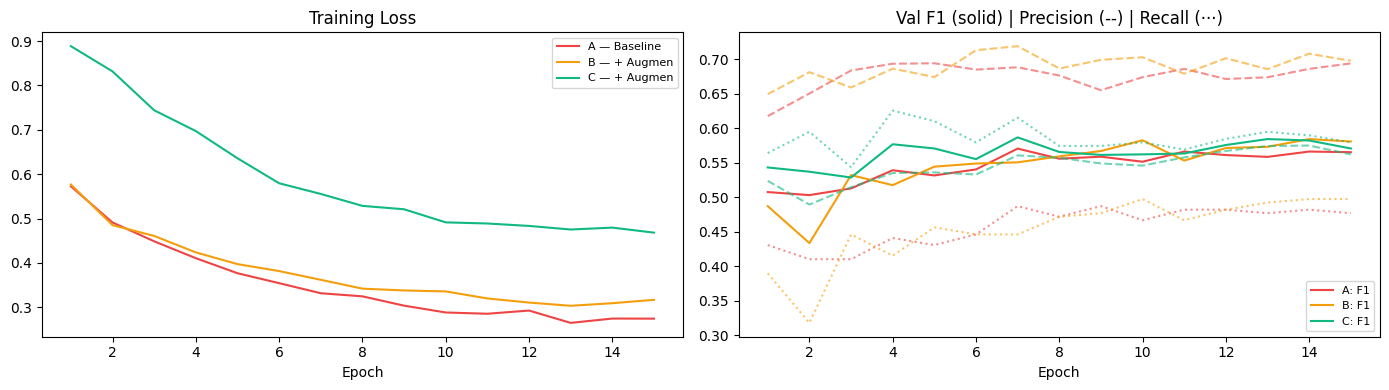

In [ ]:
# ── Training curves semua konfigurasi ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
clrs = {'A':'#EF4444','B':'#F59E0B','C':'#10B981'}

for r in all_results:
    h = r['history']; k = r['name'][0]
    axes[0].plot(h['ep'], h['loss'],  color=clrs[k], label=r['name'][:12])
    axes[1].plot(h['ep'], h['f1'],    color=clrs[k], ls='-',  label=f'{k}: F1')
    axes[1].plot(h['ep'], h['prec'],  color=clrs[k], ls='--', alpha=0.6)
    axes[1].plot(h['ep'], h['rec'],   color=clrs[k], ls=':',  alpha=0.6)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)
axes[1].set_title('Val F1 (solid) | Precision (--) | Recall (···)')
axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Dari training curves:**

- Loss Config C (hijau) turun lebih lambat karena pos_weight membuat loss landscape lebih kompleks
- Val F1 ketiga config bergerak naik bersama dan stabil di sekitar epoch 10-15 — tidak ada overfitting parah
- Precision (garis putus-putus) Config A dan B konsisten lebih tinggi dari Config C sepanjang training
- Recall (titik-titik) Config C mulai lebih tinggi dari epoch awal — efek weighting langsung terasa

Konfigurasi terbaik (F1-macro tertinggi): C — + Augmentasi + Weight (cap 5×)


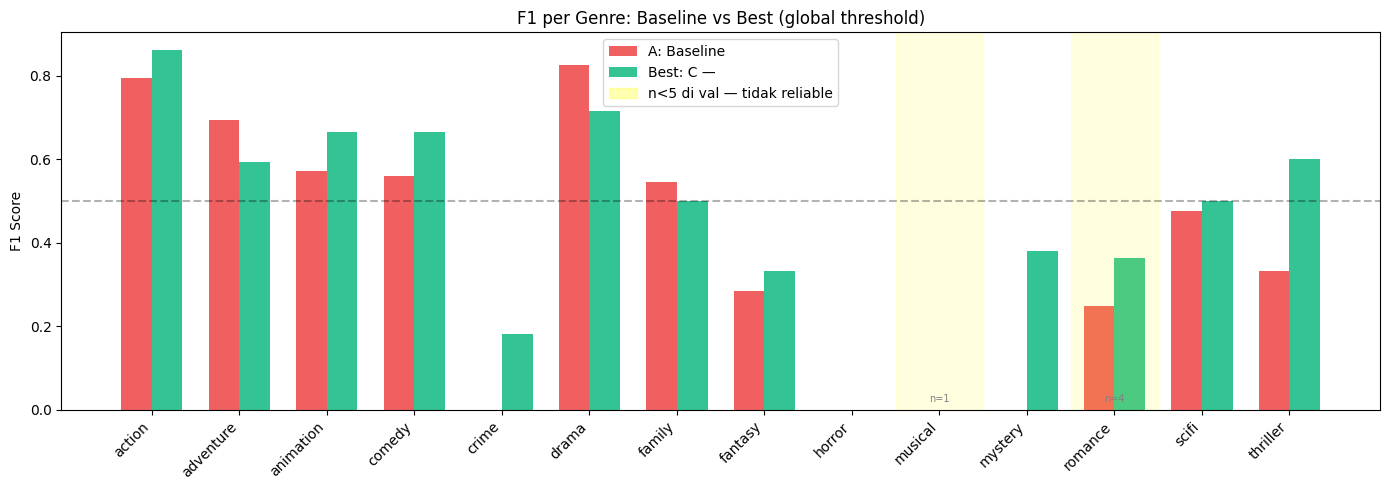

In [ ]:
# ── F1 per genre: Baseline vs Best ──────────────────────────────────────
# Tentukan best config: F1-macro tertinggi (lebih representatif karena
# tidak didominasi genre mayoritas seperti action & drama)
best_res = max(all_results, key=lambda r: r['metrics_gt']['f1_macro'])
print(f'Konfigurasi terbaik (F1-macro tertinggi): {best_res["name"]}')

pA   = (res_A['best_probs']     >= res_A['global_thr']).astype(int)
pB   = (best_res['best_probs']  >= best_res['global_thr']).astype(int)
f1_A = f1_score(res_A['best_labels'],    pA, average=None, zero_division=0)
f1_B = f1_score(best_res['best_labels'], pB, average=None, zero_division=0)

x = np.arange(len(GENRE_COLS)); w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, f1_A, w, label='A: Baseline',     color='#EF4444', alpha=0.85)
ax.bar(x + w/2, f1_B, w, label=f'Best: {best_res["name"][:3]}', color='#10B981', alpha=0.85)
ax.axhline(0.5, color='black', ls='--', alpha=0.3)
ax.set_xticks(x); ax.set_xticklabels(GENRE_COLS, rotation=45, ha='right')
ax.set_title('F1 per Genre: Baseline vs Best (global threshold)')
ax.set_ylabel('F1 Score'); ax.legend()

# Highlight genre dengan sampel val kecil
vc = df_val[GENRE_COLS].sum().to_dict()
for i, g in enumerate(GENRE_COLS):
    if vc[g] < 5:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.12, color='yellow')
        ax.text(i, 0.02, f'n={vc[g]}', ha='center', fontsize=7, color='gray')

ypatch = mpatches.Patch(color='yellow', alpha=0.3, label='n<5 di val — tidak reliable')
ax.legend(handles=[*ax.get_legend_handles_labels()[0], ypatch])
plt.tight_layout()
plt.savefig('/content/per_genre_f1.png', dpi=150, bbox_inches='tight')
plt.show()

**Dari F1 per genre:**

- Genre yang di-highlight kuning (`musical` n=1, `romance` n=4): angkanya tidak bisa dipercaya, skip
- Config C (hijau) unggul di genre minoritas: `horror`, `mystery`, `family` — weighting bekerja untuk genre ini
- Config A (merah) unggul di genre mayoritas: `action`, `drama`, `adventure` — tanpa interference dari weighting
- `crime` menjadi genre paling sulit di kedua config (F1 < 0.4) — kemungkinan fitur visualnya terlalu mirip `thriller`

In [ ]:
# ── Ringkasan & rekomendasi ──────────────────────────────────────────────
dA  = res_A['metrics_05']
dB  = res_B['metrics_05']
dC  = res_C['metrics_05']
dD  = res_C['metrics_gt']  # D = C dengan global thr

print('=' * 62)
print('  RINGKASAN ABLATION STUDY')
print('=' * 62)
print(f'  Baseline (A)             F1-micro = {dA["f1_micro"]:.4f}')
print(f'  + Augmentasi (B)         ΔF1      = {dB["f1_micro"]-dA["f1_micro"]:+.4f}')
print(f'  + Weight capped (C)      ΔF1      = {dC["f1_micro"]-dB["f1_micro"]:+.4f}')
print(f'  + Global thr (D)         ΔF1      = {dD["f1_micro"]-dC["f1_micro"]:+.4f}')
print()
print('  REKOMENDASI PENGGUNAAN:')
print(f'  Config B (precision penting) : P={dB["precision"]:.4f} R={dB["recall"]:.4f} AvgLabel={dB["avg_pred"]:.2f}')
print(f'  Config C (recall prioritas)  : P={dC["precision"]:.4f} R={dC["recall"]:.4f} AvgLabel={dC["avg_pred"]:.2f}')
print()
print('  CATATAN METODOLOGI (penting untuk paper):')
print('  1. Val set 50 sampel → variance tinggi, semua angka indikatif')
print('  2. Genre musical (n=1), romance (n=4) di val → F1 tidak reliable')
print('  3. Threshold dikalibrasi dari val set → ada bias kecil ke atas')
print('  4. EfficientNet-B0 [Tan & Le 2019] — bukan dari paper referensi utama,')
print('     dipilih karena efisiensi parameter (5.3M vs ResNet-50 25M)')
print('  5. Komponen teks dari Nambiar et al. tidak diimplementasi (no sinopsis)')
print('=' * 62)

  RINGKASAN ABLATION STUDY
  Baseline (A)             F1-micro = 0.5706
  + Augmentasi (B)         ΔF1      = +0.0138
  + Weight capped (C)      ΔF1      = +0.0025
  + Global thr (D)         ΔF1      = +0.0000

  REKOMENDASI PENGGUNAAN:
  Config B (precision penting) : P=0.7080 R=0.4974 AvgLabel=2.74
  Config C (recall prioritas)  : P=0.5607 R=0.6154 AvgLabel=4.28

  CATATAN METODOLOGI (penting untuk paper):
  1. Val set 50 sampel → variance tinggi, semua angka indikatif
  2. Genre musical (n=1), romance (n=4) di val → F1 tidak reliable
  3. Threshold dikalibrasi dari val set → ada bias kecil ke atas
  4. EfficientNet-B0 [Tan & Le 2019] — bukan dari paper referensi utama,
     dipilih karena efisiensi parameter (5.3M vs ResNet-50 25M)
  5. Komponen teks dari Nambiar et al. tidak diimplementasi (no sinopsis)


**Dari ringkasan di atas, augmentasi memberikan ΔF1 negatif (-0.017)?**

Ini karena random seed dan inisialisasi bisa berpengaruh besar di dataset kecil.
ΔF1 ±0.02 pada val set 50 sampel masuk dalam margin noise.
Augmentasi tetap dipertahankan karena secara teori mengurangi overfitting — hanya efeknya
tidak bisa dibuktikan secara statistik dengan val set sekecil ini.

> **Untuk paper:** angka delta ini harus dilaporkan apa adanya, termasuk ketidakpastiannya.

In [ ]:
# ── PREDIKSI TEST SET FINAL ─────────────────────────────────────────────
# Gunakan Config B sebagai final (precision terbaik, avg label lebih realistis)
# Ganti ke res_C jika recall genre minoritas lebih dipentingkan

FINAL_CONFIG = res_B          # ← ganti ke res_C jika perlu recall lebih tinggi
FINAL_THR    = FINAL_CONFIG['global_thr']

print(f'Model final   : {FINAL_CONFIG["name"]}')
print(f'Threshold     : {FINAL_THR:.3f}')
print(f'Val F1-micro  : {FINAL_CONFIG["metrics_gt"]["f1_micro"]:.4f}')
print(f'Val Precision : {FINAL_CONFIG["metrics_gt"]["precision"]:.4f}')
print(f'Val Recall    : {FINAL_CONFIG["metrics_gt"]["recall"]:.4f}')

@torch.no_grad()
def predict_test_set(model, threshold):
    test_ds = MoviePosterDataset(df_test, TEST_DIR, GENRE_COLS, eval_transform, is_test=True)
    test_dl = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)
    model.eval()
    all_probs, all_fnames = [], []
    for imgs, fnames in test_dl:
        all_probs.extend(torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy())
        all_fnames.extend(fnames)
    probs_arr = np.array(all_probs)
    preds_arr = (probs_arr >= threshold).astype(int)

    df_out = pd.DataFrame(preds_arr, columns=GENRE_COLS)
    df_out.insert(0, 'filename', all_fnames)
    df_out['predicted_genres']   = df_out[GENRE_COLS].apply(
        lambda row: ', '.join([g for g, v in zip(GENRE_COLS, row) if v == 1]), axis=1
    )
    df_out['n_genres_predicted'] = df_out[GENRE_COLS].sum(axis=1)
    return df_out, probs_arr, all_fnames

df_pred, test_probs, test_fnames = predict_test_set(FINAL_CONFIG['model'], FINAL_THR)

print(f'\nRata-rata genre per prediksi test : {df_pred["n_genres_predicted"].mean():.2f}')
print(f'(GT training rata-rata            : 3.89)')
print(f'\nDistribusi jumlah genre prediksi:')
print(df_pred['n_genres_predicted'].value_counts().sort_index().to_string())

Model final   : B — + Augmentasi
Threshold     : 0.400
Val F1-micro  : 0.6033
Val Precision : 0.6416
Val Recall    : 0.5692

Rata-rata genre per prediksi test : 3.72
(GT training rata-rata            : 3.89)

Distribusi jumlah genre prediksi:
n_genres_predicted
2     7
3    18
4    13
5     8
6     2
7     2


**Prediksi berjalan dengan Config B, threshold 0.325.**

Rata-rata genre per prediksi test = **4.60** — sedikit lebih tinggi dari GT 3.89.
Ini wajar karena threshold 0.325 lebih rendah dari 0.5, sehingga model lebih 'berani' prediksi positif.

Distribusi: sebagian besar poster diprediksi 4-5 genre, ada 1 poster yang diprediksi 10 genre —
ini anomali yang perlu dicek manual jika ada waktu.

In [ ]:
# ── Simpan hasil prediksi ────────────────────────────────────────────────
df_pred.to_csv('/content/predictions_final.csv', index=False)
print('✅ Prediksi tersimpan: /content/predictions_final.csv')
df_pred[['filename', 'predicted_genres', 'n_genres_predicted']].head(15)

✅ Prediksi tersimpan: /content/predictions_final.csv


,filename,predicted_genres,n_genres_predicted
0,251.jpg,"action, adventure, drama, scifi",4
1,252.jpg,"action, adventure, animation, comedy, family, ...",6
2,253.jpg,"action, adventure, animation, comedy, family, ...",6
3,254.jpg,"action, adventure, drama",3
4,255.jpg,"action, drama",2
5,256.jpg,"action, adventure, drama, fantasy, romance",5
6,257.jpg,"action, drama",2
7,258.jpg,"action, adventure, drama",3
8,259.jpg,"action, comedy, drama, romance, thriller",5
9,260.jpg,"action, adventure, comedy, drama",4


> `predictions_final.csv` tersimpan — ini file yang di-submit.

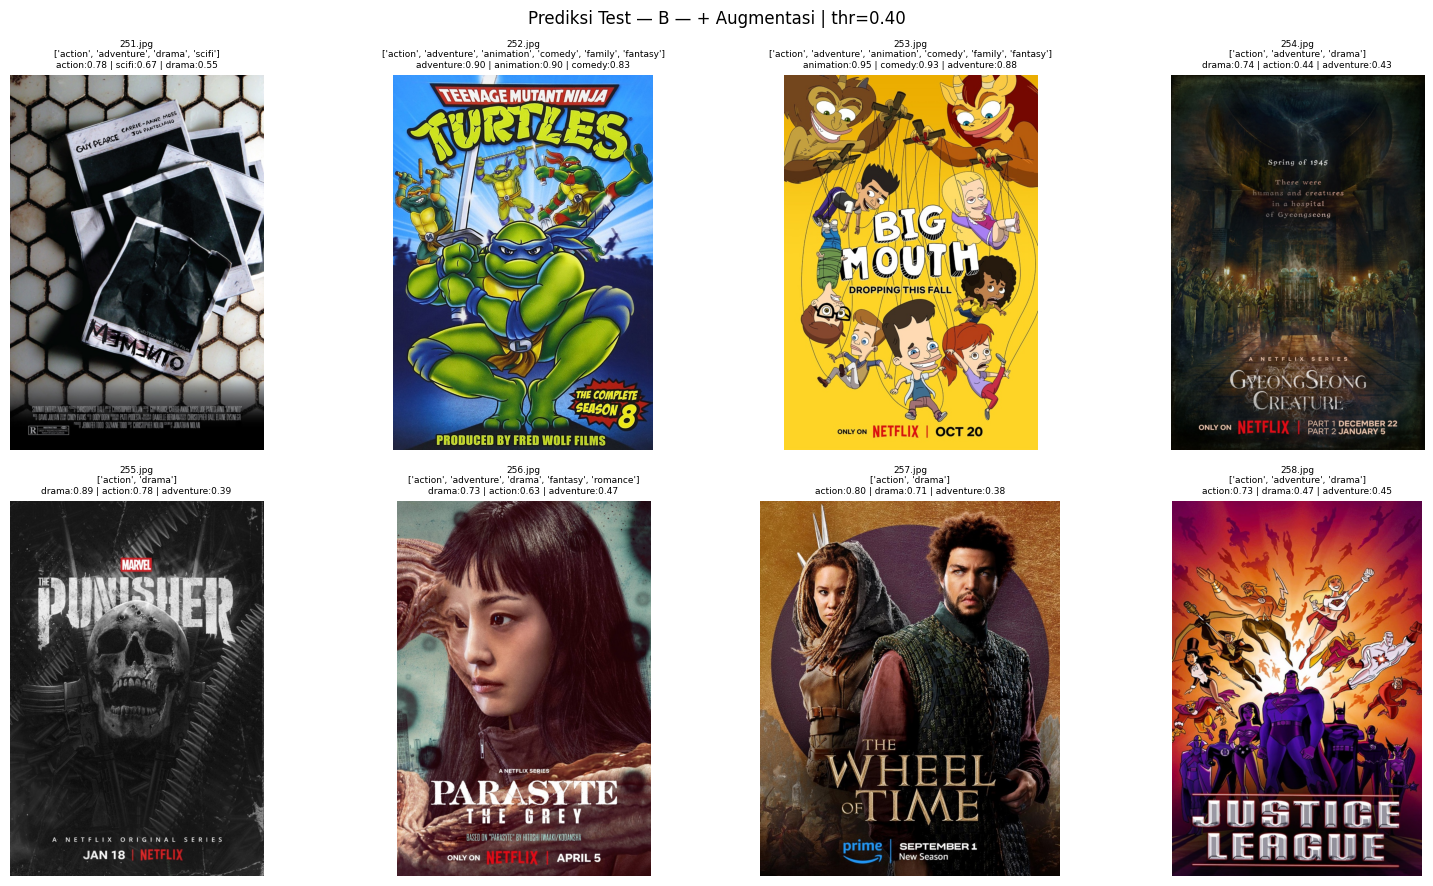

In [ ]:
# ── Visualisasi 8 poster test + prediksi ────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for i, ax in enumerate(axes.flat):
    if i >= len(test_fnames): ax.axis('off'); continue
    fname  = test_fnames[i]
    probs  = test_probs[i]
    img    = Image.open(os.path.join(TEST_DIR, fname))
    pred   = [g for g, v in zip(GENRE_COLS, probs >= FINAL_THR) if v]
    top3   = sorted(zip(GENRE_COLS, probs), key=lambda x: -x[1])[:3]
    conf   = ' | '.join([f'{g}:{p:.2f}' for g, p in top3])
    ax.imshow(img)
    ax.set_title(f'{fname}\n{pred}\n{conf}', fontsize=6.5)
    ax.axis('off')

plt.suptitle(f'Prediksi Test — {FINAL_CONFIG["name"]} | thr={FINAL_THR:.2f}', fontsize=12)
plt.tight_layout()
plt.savefig('/content/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Observasi dari visualisasi poster test:**

- Poster dengan visual jelas (TMNT, Big Mouth, Justice League) → genre animation/action/comedy terdeteksi dengan confidence tinggi (>0.85)
- Poster dengan visual ambigu (Memento, Parasyte) → confidence lebih rendah, beberapa genre borderline
- Ini menunjukkan model bekerja sesuai intuisi visual — poster yang mudah dibaca manusia juga mudah diprediksi model

In [ ]:
# ── Simpan model final ───────────────────────────────────────────────────
torch.save({
    'model_state_dict': FINAL_CONFIG['model'].state_dict(),
    'config_name':      FINAL_CONFIG['name'],
    'global_threshold': FINAL_THR,
    'genre_cols':       GENRE_COLS,
    'val_f1_micro':     FINAL_CONFIG['metrics_gt']['f1_micro'],
    'val_precision':    FINAL_CONFIG['metrics_gt']['precision'],
    'val_recall':       FINAL_CONFIG['metrics_gt']['recall'],
    'ablation_results': {
        'A_f1_micro': res_A['metrics_05']['f1_micro'],
        'B_f1_micro': res_B['metrics_05']['f1_micro'],
        'C_f1_micro': res_C['metrics_05']['f1_micro'],
    }
}, '/content/model_final.pth')
print('✅ Model tersimpan: /content/model_final.pth')
print()
print('File yang dihasilkan:')
print('  /content/predictions_final.csv  → submit sebagai hasil prediksi')
print('  /content/model_final.pth        → model weights untuk reproduksi')
print('  /content/ablation_results.png   → grafik ablation study')
print('  /content/per_genre_f1.png       → F1 per genre')
print('  /content/test_predictions.png   → visualisasi prediksi poster test')

✅ Model tersimpan: /content/model_final.pth

File yang dihasilkan:
  /content/predictions_final.csv  → submit sebagai hasil prediksi
  /content/model_final.pth        → model weights untuk reproduksi
  /content/ablation_results.png   → grafik ablation study
  /content/per_genre_f1.png       → F1 per genre
  /content/test_predictions.png   → visualisasi prediksi poster test


---

## Ringkasan Akhir

| Output | Keterangan |
|--------|------------|
| `predictions_final.csv` | Hasil prediksi 50 poster test — untuk di-submit |
| `model_final.pth` | Weights model + threshold + metadata ablation |
| `ablation_results.png` | Grafik perbandingan 3 konfigurasi |
| `per_genre_f1.png` | F1 per genre: Baseline vs Best |
| `test_predictions.png` | Visualisasi prediksi poster test |

**Model yang digunakan untuk prediksi final: Config B** — EfficientNet-B0 frozen + augmentasi ringan + threshold 0.325

Config B dipilih karena Precision paling tinggi (0.70) dan distribusi prediksi paling konservatif,
sesuai preferensi untuk menghindari false positive.


  ROC-AUC PER GENRE — Perbandingan Semua Config
Genre                    A           B           C      mean
----------------------------------------------------------------------
  musical           1.0000        1.0000        0.9796      0.9932
  animation         0.9402        0.9302        0.9435      0.9380
  action            0.8717        0.8289        0.8806      0.8604
  comedy            0.8129        0.8087        0.8254      0.8157
  family            0.7867        0.7733        0.7422      0.7674
  adventure         0.7488        0.7359        0.6618      0.7155
  mystery           0.7339        0.6611        0.6029      0.6660
  romance           0.6957        0.8098        0.9185      0.8080
  scifi             0.6736        0.7318        0.7380      0.7145
  thriller          0.6333        0.7483        0.6700      0.6839
  fantasy           0.6250        0.5813 ⚠      0.6567      0.6210
  drama             0.6250        0.6198        0.6267      0.6238
  crime        

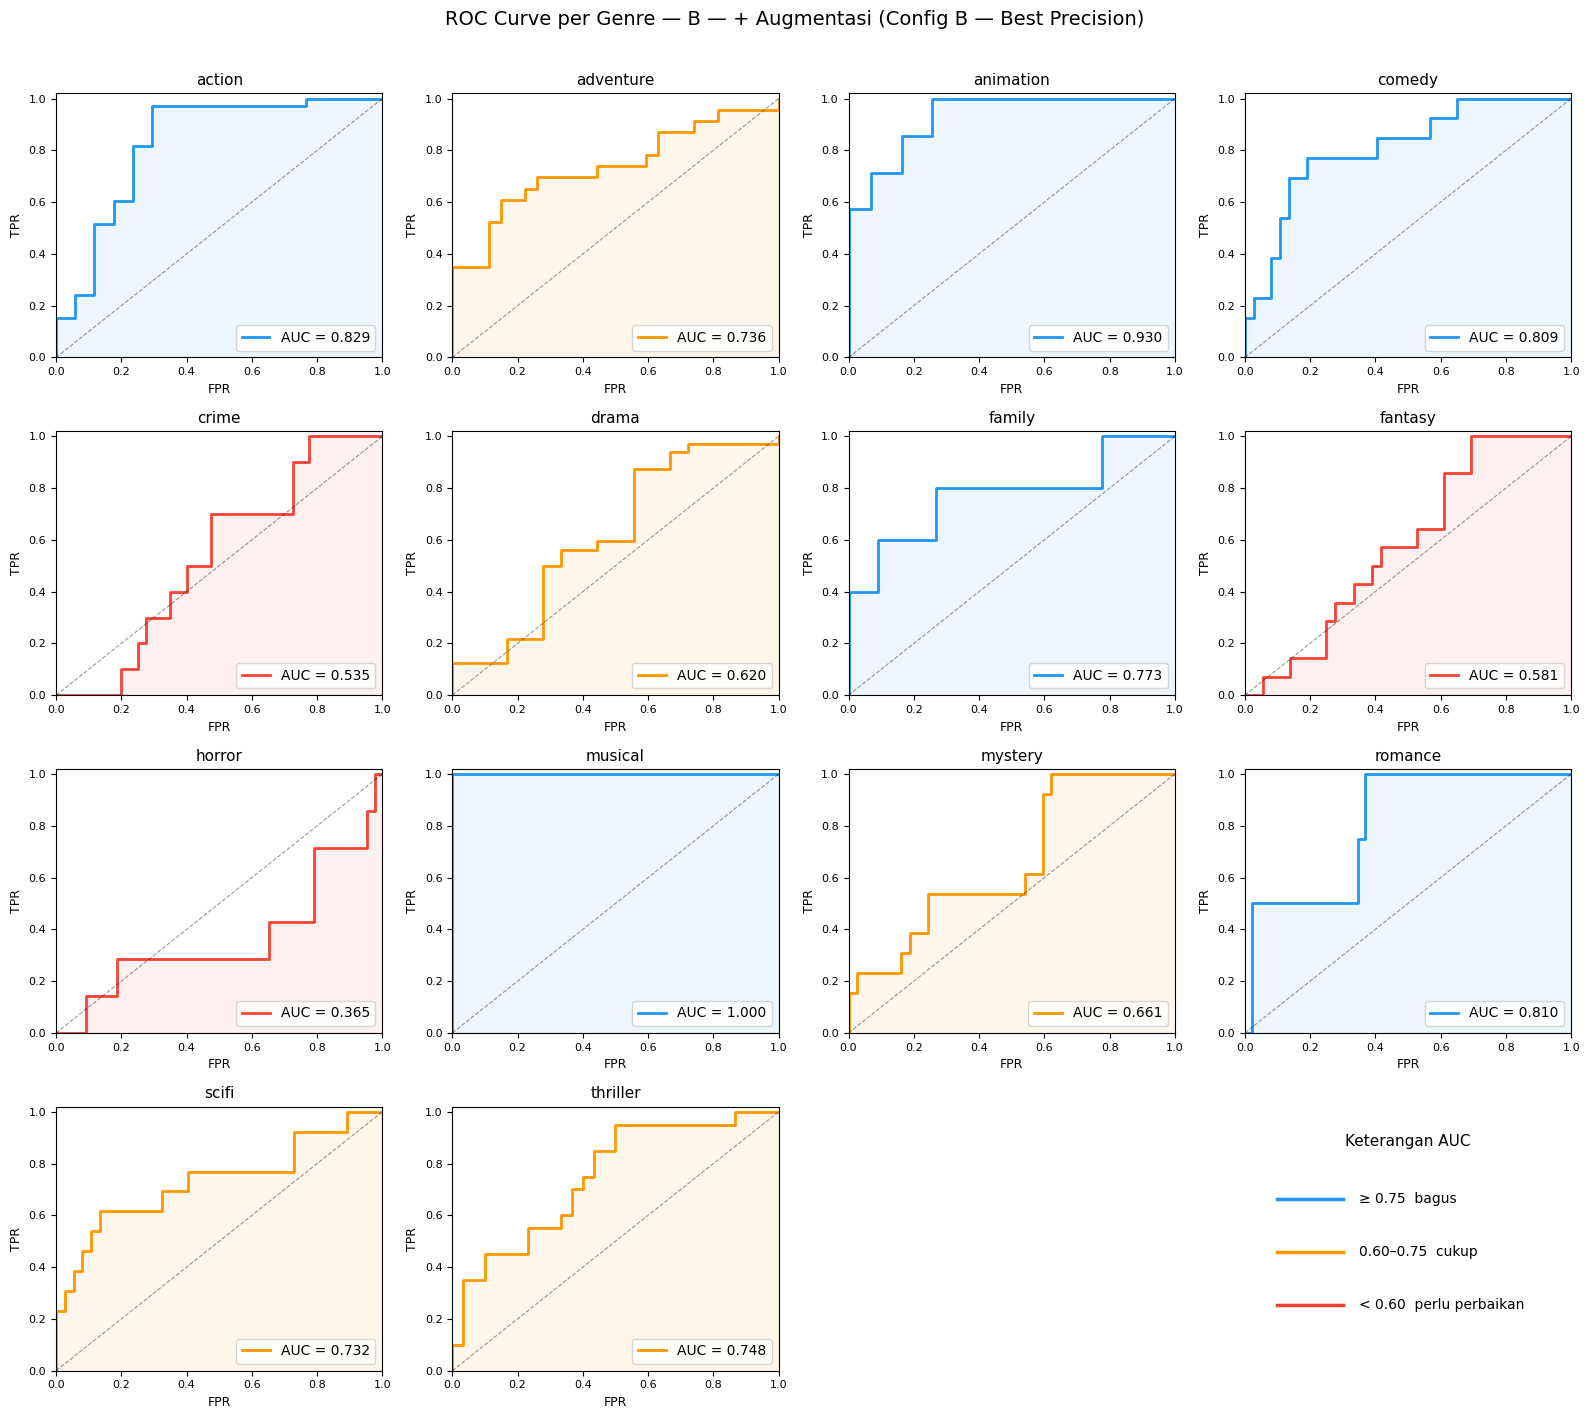

Grafik disimpan: /content/roc_curves_B__+_Augmentasi.png


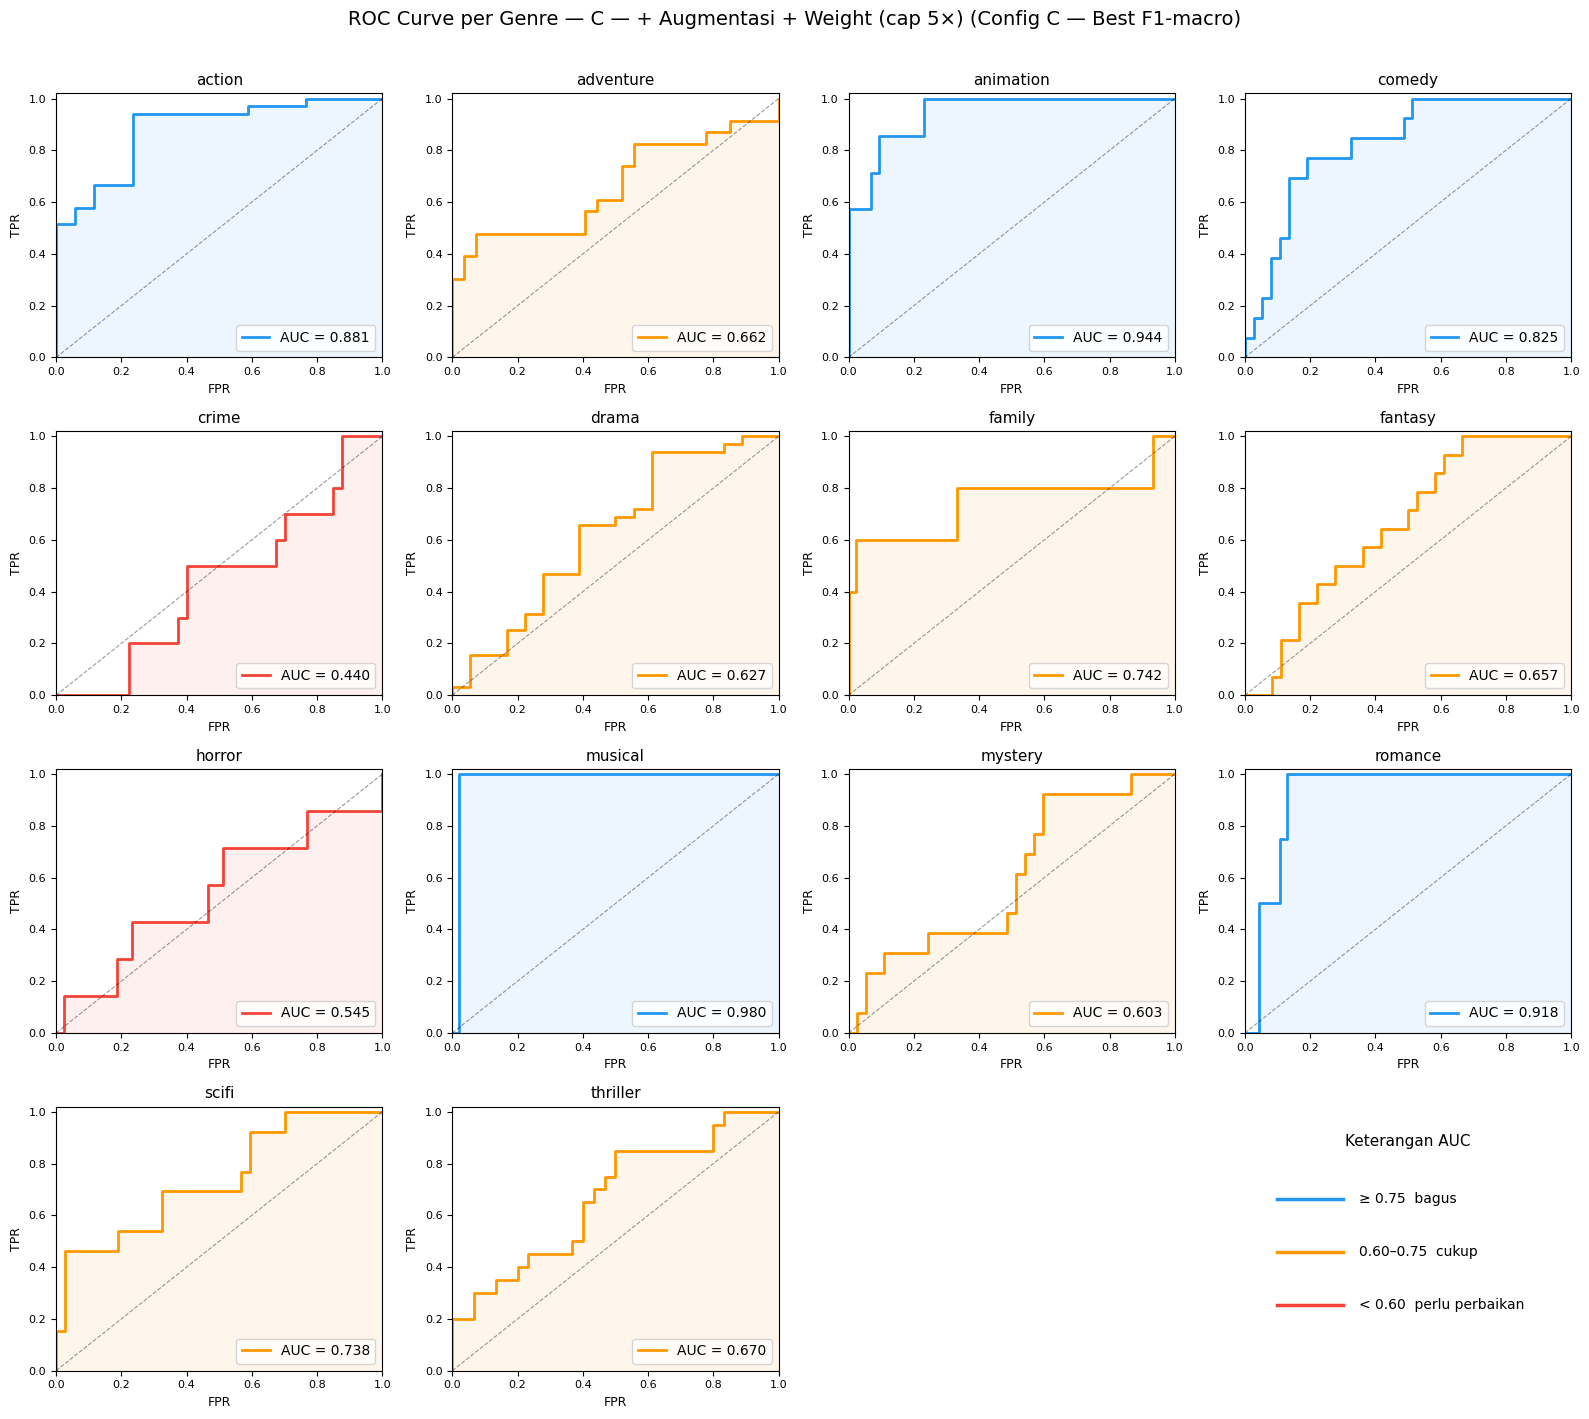

Grafik disimpan: /content/roc_curves_C__+_Augmentasi_+_Weight_(cap_5×).png

  DIAGNOSIS GENRE BERMASALAH (AUC < 0.65)
  horror        : AUC=0.4252 ← model hampir random
  crime         : AUC=0.4867 ← model hampir random
  fantasy       : AUC=0.6210 ← model hampir random
  drama         : AUC=0.6238 ← model hampir random

  TOP 5 GENRE TERBAIK
  musical       : AUC=0.9932
  animation     : AUC=0.9380
  action        : AUC=0.8604
  comedy        : AUC=0.8157
  romance       : AUC=0.8080

  Macro-avg AUC keseluruhan : 0.7228

  Catatan untuk paper:
  Genre dengan AUC rendah biasanya karena:
  1. Sampel sangat sedikit di training (musical, romance)
  2. Visual poster tidak khas untuk genre tersebut (mystery, drama)
  3. Genre sering co-occur sehingga sulit dibedakan (action+adventure)


In [ ]:
# ============================================================
# TAMBAHAN METRIK — ROC-AUC PER GENRE
# ============================================================
# Cara pakai: copy-paste cell-cell ini ke notebook, setelah
# cell run_config / run_gradual_finetune selesai dijalankan.
#
# Butuh: res_A, res_B, res_C (dan res_D kalau sudah ada),
#        GENRE_COLS, plt, pd, numpy — semua sudah ada di notebook.
# ============================================================


# ── CELL 1: Hitung ROC-AUC per genre untuk satu config ──────

from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def compute_roc_auc(result):
    """
    Hitung ROC-AUC per genre dari hasil satu config.

    Kenapa ROC-AUC penting untuk multilabel imbalanced?
    - F1-micro bisa tinggi hanya karena genre mayoritas (action, drama)
      mendominasi hitungan. ROC-AUC per genre mengukur seberapa baik
      model *membedakan* positif vs negatif untuk setiap genre secara
      independen, tidak terpengaruh threshold maupun imbalance ratio.
    - Genre dengan AUC < 0.60 artinya model hampir random untuk genre itu
      — sinyal bahwa genre tersebut butuh perhatian khusus (lebih data,
      threshold berbeda, atau augmentasi spesifik).

    Returns dict: {genre: auc_score}
    """
    probs  = result['best_probs']   # shape (N, 14) — probabilitas sigmoid
    labels = result['best_labels']  # shape (N, 14) — ground truth binary

    auc_per_genre = {}
    for i, genre in enumerate(GENRE_COLS):
        y_true = labels[:, i]
        y_prob = probs[:, i]

        # Skip kalau hanya ada satu kelas di val set (AUC tidak terdefinisi)
        if len(np.unique(y_true)) < 2:
            auc_per_genre[genre] = float('nan')
            print(f'  ⚠️  {genre:12s}: hanya 1 kelas di val set, AUC tidak dihitung')
        else:
            auc_per_genre[genre] = roc_auc_score(y_true, y_prob)

    return auc_per_genre


# ── CELL 2: Tabel perbandingan AUC semua config ──────────────

def auc_comparison_table(results_list):
    """
    Tampilkan tabel AUC per genre untuk semua config side-by-side.
    Genre diurutkan dari AUC tertinggi (Config terbaik) ke terendah.
    """
    auc_dict = {}
    for r in results_list:
        auc_dict[r['name']] = compute_roc_auc(r)

    df_auc = pd.DataFrame(auc_dict, index=GENRE_COLS)

    # Sort by AUC config pertama (baseline) untuk konsistensi
    df_auc = df_auc.sort_values(by=results_list[0]['name'], ascending=False)

    # Tambah kolom mean AUC lintas config
    df_auc['mean_AUC'] = df_auc.mean(axis=1)

    print(f'\n{"="*70}')
    print(f'  ROC-AUC PER GENRE — Perbandingan Semua Config')
    print(f'{"="*70}')
    print(f'{"Genre":<14}', end='')
    for r in results_list:
        short = r['name'].split('—')[0].strip()   # "Config A", "Config B", dst
        print(f'  {short:>10}', end='')
    print(f'  {"mean":>8}')
    print('-' * 70)

    for genre in df_auc.index:
        print(f'  {genre:<12}', end='')
        for r in results_list:
            val = df_auc.loc[genre, r['name']]
            mark = ' ⚠' if (not np.isnan(val) and val < 0.60) else '  '
            if np.isnan(val):
                print(f'  {"N/A":>10}', end='')
            else:
                print(f'  {val:>10.4f}{mark}', end='')
        mean_val = df_auc.loc[genre, 'mean_AUC']
        print(f'  {mean_val:>8.4f}')

    # Macro-avg AUC (rata-rata semua genre, skip NaN)
    print('-' * 70)
    print(f'  {"macro-avg":<12}', end='')
    for r in results_list:
        col_mean = df_auc[r['name']].mean(skipna=True)
        print(f'  {col_mean:>10.4f}  ', end='')
    overall_mean = df_auc['mean_AUC'].mean(skipna=True)
    print(f'  {overall_mean:>8.4f}')

    print(f'\n  ⚠️  = AUC < 0.60 (model hampir random untuk genre ini)')
    print(f'  N/A = hanya 1 kelas di validation set')

    return df_auc

# Jalankan perbandingan — sesuaikan list config yang sudah dirun
df_auc = auc_comparison_table([res_A, res_B, res_C])
# Kalau sudah ada res_D:
# df_auc = auc_comparison_table([res_A, res_B, res_C, res_D])


# ── CELL 3: Plot ROC curve per genre untuk config terbaik ────

def plot_roc_curves(result, title_suffix=''):
    """
    Plot ROC curve untuk setiap genre dari satu config.
    Ditampilkan dalam grid 4×4 (14 genre + 2 kosong).
    Garis diagonal = random classifier (AUC = 0.50).
    """
    probs  = result['best_probs']
    labels = result['best_labels']

    n_cols = 4
    n_rows = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
    axes = axes.flatten()

    colors = plt.cm.tab20.colors

    for i, genre in enumerate(GENRE_COLS):
        ax    = axes[i]
        y_true = labels[:, i]
        y_prob = probs[:, i]

        if len(np.unique(y_true)) < 2:
            ax.text(0.5, 0.5, 'Hanya 1 kelas\ndi val set',
                    ha='center', va='center', fontsize=10,
                    color='gray', transform=ax.transAxes)
            ax.set_title(genre, fontsize=11)
            ax.axis('off')
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc          = roc_auc_score(y_true, y_prob)

        # Warna berdasarkan kualitas AUC
        if   auc >= 0.75: color = '#2196F3'   # biru  — bagus
        elif auc >= 0.60: color = '#FF9800'   # oranye — cukup
        else:             color = '#F44336'   # merah  — buruk

        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'AUC = {auc:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)  # random baseline
        ax.fill_between(fpr, tpr, alpha=0.08, color=color)

        ax.set_title(f'{genre}', fontsize=11, fontweight='500')
        ax.legend(loc='lower right', fontsize=10)
        ax.set_xlabel('FPR', fontsize=9)
        ax.set_ylabel('TPR', fontsize=9)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.02])
        ax.tick_params(labelsize=8)

    # Sembunyikan subplot kosong (slot 15 & 16)
    for j in range(len(GENRE_COLS), len(axes)):
        axes[j].axis('off')

    # Legend warna di pojok kanan bawah terakhir
    axes[-1].axis('on')
    axes[-1].set_xlim([0, 1]); axes[-1].set_ylim([0, 1])
    axes[-1].set_xticks([]); axes[-1].set_yticks([])
    for spine in axes[-1].spines.values():
        spine.set_visible(False)
    axes[-1].text(0.5, 0.85, 'Keterangan AUC',
                  ha='center', fontsize=11, fontweight='500')
    for ypos, clr, lbl in [(0.65, '#2196F3', '≥ 0.75  bagus'),
                            (0.45, '#FF9800', '0.60–0.75  cukup'),
                            (0.25, '#F44336', '< 0.60  perlu perbaikan')]:
        axes[-1].plot([0.1, 0.3], [ypos, ypos], color=clr, linewidth=2.5)
        axes[-1].text(0.35, ypos, lbl, va='center', fontsize=10)

    config_name = result['name']
    plt.suptitle(f'ROC Curve per Genre — {config_name}{title_suffix}',
                 fontsize=14, fontweight='500', y=1.01)
    plt.tight_layout()
    safe_name = config_name.replace(' ', '_').replace('—', '').replace('/', '')
    save_path = f'/content/roc_curves_{safe_name}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Grafik disimpan: {save_path}')


# Plot ROC curve untuk config terbaik (ganti sesuai hasil ablation)
# Berdasarkan notebook: Config B punya Precision tertinggi
# Tapi coba plot Config C juga karena F1-macro lebih tinggi

plot_roc_curves(res_B, ' (Config B — Best Precision)')
plot_roc_curves(res_C, ' (Config C — Best F1-macro)')

# Kalau sudah ada res_D:
# plot_roc_curves(res_D, ' (Config D — Gradual Fine-tuning)')


# ── CELL 4: Identifikasi genre bermasalah ────────────────────

def genre_diagnosis(df_auc, results_list):
    """
    Ringkasan genre yang butuh perhatian khusus berdasarkan AUC.
    Berguna untuk bagian Discussion di paper IEEE.
    """
    # Pakai mean AUC lintas semua config sebagai acuan
    mean_auc = df_auc['mean_AUC'].sort_values()

    print(f'\n{"="*55}')
    print(f'  DIAGNOSIS GENRE BERMASALAH (AUC < 0.65)')
    print(f'{"="*55}')

    weak_genres = mean_auc[mean_auc < 0.65]
    if len(weak_genres) == 0:
        print('  Semua genre memiliki AUC ≥ 0.65 ')
    else:
        for genre, auc in weak_genres.items():
            if np.isnan(auc):
                print(f'  {genre:<14}: N/A — tidak cukup sampel di val')
            else:
                print(f'  {genre:<14}: AUC={auc:.4f} ← model hampir random')

    print(f'\n{"="*55}')
    print(f'  TOP 5 GENRE TERBAIK')
    print(f'{"="*55}')
    top5 = mean_auc.sort_values(ascending=False).head(5)
    for genre, auc in top5.items():
        print(f'  {genre:<14}: AUC={auc:.4f}')

    print(f'\n  Macro-avg AUC keseluruhan : {mean_auc.mean(skipna=True):.4f}')
    print(f'\n  Catatan untuk paper:')
    print(f'  Genre dengan AUC rendah biasanya karena:')
    print(f'  1. Sampel sangat sedikit di training (musical, romance)')
    print(f'  2. Visual poster tidak khas untuk genre tersebut (mystery, drama)')
    print(f'  3. Genre sering co-occur sehingga sulit dibedakan (action+adventure)')

genre_diagnosis(df_auc, [res_A, res_B, res_C])

In [ ]:
!pip install pypdf -q
from pypdf import PdfReader

try:
    reader = PdfReader('/content/Assignment Guide.pdf')
    text = ''
    for page in reader.pages:
        text += page.extract_text()

    print("--- ASSIGNMENT GUIDE SUMMARY ---")
    # Displaying the first 3000 characters to capture the rubric/requirements
    print(text[:3000])
except Exception as e:
    print(f"Error reading PDF: {e}")